In [1]:
print("hello")

hello


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load both files
df1 = pd.read_excel('C:/Users/chint/solar-iot-monitor/data/JAN 1ST - JAN 7TH.xls', 
                    engine='xlrd', sheet_name=0, header=None, skiprows=2)
df2 = pd.read_excel('C:/Users/chint/solar-iot-monitor/data/JAN 8TH - JAN14TH.xls', 
                    engine='xlrd', sheet_name=0, header=None, skiprows=2)

# Add column names
cols = ['Time', 'Working_Mode', 'V_MPPT1', 'V_MPPT2', 'V_MPPT3', 
        'I_MPPT1', 'I_MPPT2', 'I_MPPT3', 'Power_W', 'Total_Gen_kWh', 
        'I_AC1', 'I_AC2', 'I_AC3', 'Ua', 'Ub', 'Uc', 'Temperature']

df1.columns = cols
df2.columns = cols

# Combine
df['Time'] = pd.to_datetime(df['Time'], format='mixed', dayfirst=True)

# Clean
df = df[df['Time'].notna()]
df = df[df['Time'] != 'Time']
df = df[df['Time'] != 'TOTAL']

# Convert types
df['Time'] = pd.to_datetime(df['Time'], format='%d.%m.%Y %H:%M:%S')
df['Power_W'] = pd.to_numeric(df['Power_W'], errors='coerce')
df['V_MPPT1'] = pd.to_numeric(df['V_MPPT1'], errors='coerce')
df['V_MPPT2'] = pd.to_numeric(df['V_MPPT2'], errors='coerce')
df['V_MPPT3'] = pd.to_numeric(df['V_MPPT3'], errors='coerce')
df['I_MPPT1'] = pd.to_numeric(df['I_MPPT1'], errors='coerce')
df['I_MPPT2'] = pd.to_numeric(df['I_MPPT2'], errors='coerce')
df['I_MPPT3'] = pd.to_numeric(df['I_MPPT3'], errors='coerce')
df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce')

print("Total rows:", len(df))
print("Date range:", df['Time'].min(), "to", df['Time'].max())
print("\nWorking modes:")
print(df['Working_Mode'].value_counts())

Total rows: 7879
Date range: 2026-01-01 06:27:56 to 2026-12-01 18:03:55

Working modes:
Working_Mode
Normal    7669
Wait       210
Name: count, dtype: int64


In [4]:
# Filter only Normal (daytime) readings
df_day = df[df['Working_Mode'] == 'Normal'].copy()
df_day = df_day[df_day['Power_W'] > 0].copy()

print("Daytime rows:", len(df_day))

# Engineer string-level features

# 1. String Power (V x I for each MPPT)
df_day['P_MPPT1'] = df_day['V_MPPT1'] * df_day['I_MPPT1']
df_day['P_MPPT2'] = df_day['V_MPPT2'] * df_day['I_MPPT2']
df_day['P_MPPT3'] = df_day['V_MPPT3'] * df_day['I_MPPT3']

# 2. String Voltage Imbalance (difference between strings)
df_day['V_imbalance_12'] = abs(df_day['V_MPPT1'] - df_day['V_MPPT2'])
df_day['V_imbalance_13'] = abs(df_day['V_MPPT1'] - df_day['V_MPPT3'])

# 3. String Current Imbalance
df_day['I_imbalance_12'] = abs(df_day['I_MPPT1'] - df_day['I_MPPT2'])
df_day['I_imbalance_13'] = abs(df_day['I_MPPT1'] - df_day['I_MPPT3'])

# 4. DC/AC Efficiency
df_day['DC_total'] = df_day['P_MPPT1'] + df_day['P_MPPT2'] + df_day['P_MPPT3']
df_day['DC_AC_efficiency'] = df_day['Power_W'] / (df_day['DC_total'] + 1e-6)

# 5. Temperature Corrected Power
df_day['Temp_corrected_power'] = df_day['Power_W'] / (1 - 0.004 * (df_day['Temperature'] - 25))

print("\nNew features:")
print(df_day[['V_imbalance_12', 'V_imbalance_13', 'I_imbalance_12', 'I_imbalance_13', 'DC_AC_efficiency']].describe())

Daytime rows: 7669

New features:
       V_imbalance_12  V_imbalance_13  I_imbalance_12  I_imbalance_13  \
count     7669.000000     7669.000000     7669.000000     7669.000000   
mean        18.226757      626.998435        4.636498        9.343174   
std         40.007846       50.026422        3.266739        6.647186   
min          0.000000      224.400000        0.000000        0.200000   
25%          2.600000      628.400000        1.600000        3.200000   
50%          6.100000      639.000000        4.200000        8.500000   
75%         13.600000      648.200000        7.500000       15.100000   
max        382.600000      678.800000       12.400000       24.800000   

       DC_AC_efficiency  
count       7669.000000  
mean           0.897934  
std            0.195191  
min            0.096777  
25%            0.948492  
50%            0.979483  
75%            0.985827  
max            1.032524  


In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Use only MPPT1 vs MPPT2 since MPPT3 is not connected
features = ['V_imbalance_12', 'I_imbalance_12', 'DC_AC_efficiency', 'Temp_corrected_power']

X = df_day[features].copy()
X = X.dropna()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
model.fit(X_scaled)

# Predict
df_day = df_day.loc[X.index].copy()
df_day['ANOMALY'] = model.predict(X_scaled)
df_day['ANOMALY_LABEL'] = df_day['ANOMALY'].map({1: 'Normal', -1: 'Fault'})

# Identify which string is faulty
def identify_fault(row):
    if row['ANOMALY'] == 1:
        return 'No Fault'
    elif row['V_imbalance_12'] > 50:
        if row['V_MPPT1'] < row['V_MPPT2']:
            return 'String 1 Fault'
        else:
            return 'String 2 Fault'
    elif row['I_imbalance_12'] > 5:
        if row['I_MPPT1'] < row['I_MPPT2']:
            return 'String 1 Fault'
        else:
            return 'String 2 Fault'
    else:
        return 'Inverter Fault'

df_day['FAULT_TYPE'] = df_day.apply(identify_fault, axis=1)

# Summary
print("Total readings:", len(df_day))
print("Normal:", len(df_day[df_day['ANOMALY'] == 1]))
print("Faults detected:", len(df_day[df_day['ANOMALY'] == -1]))
print("\nFault breakdown:")
print(df_day['FAULT_TYPE'].value_counts())

Total readings: 7669
Normal: 7285
Faults detected: 384

Fault breakdown:
FAULT_TYPE
No Fault          7285
String 2 Fault     285
Inverter Fault      53
String 1 Fault      46
Name: count, dtype: int64


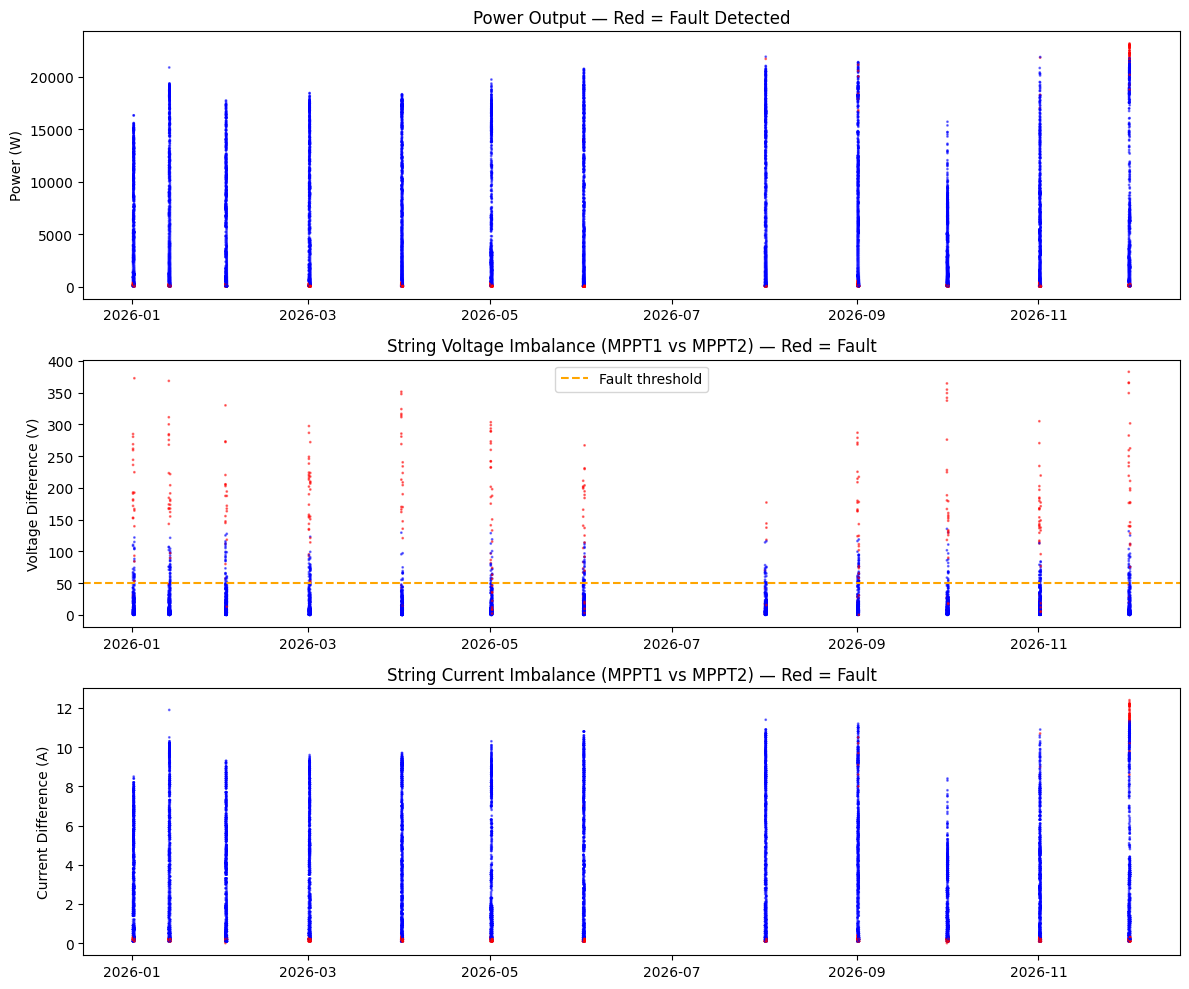

Plot saved!


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

colors = df_day['ANOMALY'].map({1: 'blue', -1: 'red'})

# Power over time
axes[0].scatter(df_day['Time'], df_day['Power_W'], c=colors, s=1, alpha=0.5)
axes[0].set_title('Power Output — Red = Fault Detected')
axes[0].set_ylabel('Power (W)')

# String voltage imbalance
axes[1].scatter(df_day['Time'], df_day['V_imbalance_12'], c=colors, s=1, alpha=0.5)
axes[1].set_title('String Voltage Imbalance (MPPT1 vs MPPT2) — Red = Fault')
axes[1].set_ylabel('Voltage Difference (V)')
axes[1].axhline(y=50, color='orange', linestyle='--', label='Fault threshold')
axes[1].legend()

# String current imbalance
axes[2].scatter(df_day['Time'], df_day['I_imbalance_12'], c=colors, s=1, alpha=0.5)
axes[2].set_title('String Current Imbalance (MPPT1 vs MPPT2) — Red = Fault')
axes[2].set_ylabel('Current Difference (A)')

plt.tight_layout()
plt.savefig('C:/Users/chint/solar-iot-monitor/data/real_fault_detection.png')
plt.show()
print("Plot saved!")


In [7]:
# Save processed real data
df_day.to_csv('C:/Users/chint/solar-iot-monitor/data/real_processed_data.csv', index=False)

# Save fault records
faults = df_day[df_day['ANOMALY'] == -1]
faults.to_csv('C:/Users/chint/solar-iot-monitor/data/real_fault_records.csv', index=False)

print("Saved real_processed_data.csv")
print("Saved real_fault_records.csv")
print(f"\nSample fault records:")
print(faults[['Time', 'Power_W', 'V_imbalance_12', 'I_imbalance_12', 'FAULT_TYPE']].head(10))

Saved real_processed_data.csv
Saved real_fault_records.csv

Sample fault records:
                  Time  Power_W  V_imbalance_12  I_imbalance_12  \
13 2026-01-01 06:37:25       34            31.8             0.1   
14 2026-01-01 06:38:27       32            29.6             0.1   
15 2026-01-01 06:39:30       35             1.9             0.1   
28 2026-01-01 06:53:05      150           152.8             0.2   
29 2026-01-01 06:54:08      164           171.5             0.2   
30 2026-01-01 06:55:11      156           192.7             0.2   
31 2026-01-01 06:56:13      188           190.8             0.3   
32 2026-01-01 06:57:16      201           261.5             0.2   
33 2026-01-01 06:58:19      208           280.3             0.2   
34 2026-01-01 06:59:22      234           268.6             0.2   

        FAULT_TYPE  
13  Inverter Fault  
14  Inverter Fault  
15  Inverter Fault  
28  String 2 Fault  
29  String 2 Fault  
30  String 2 Fault  
31  String 2 Fault  
32  String 2